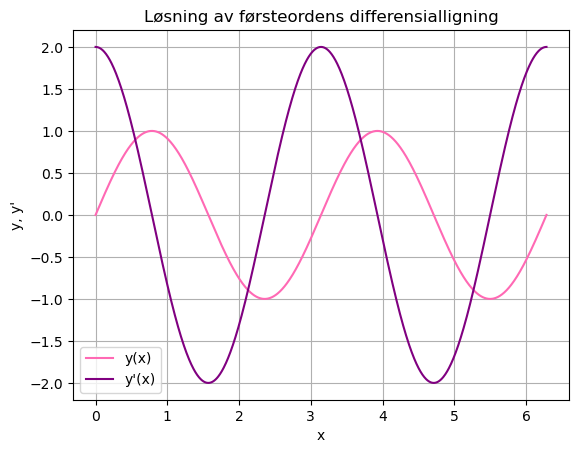

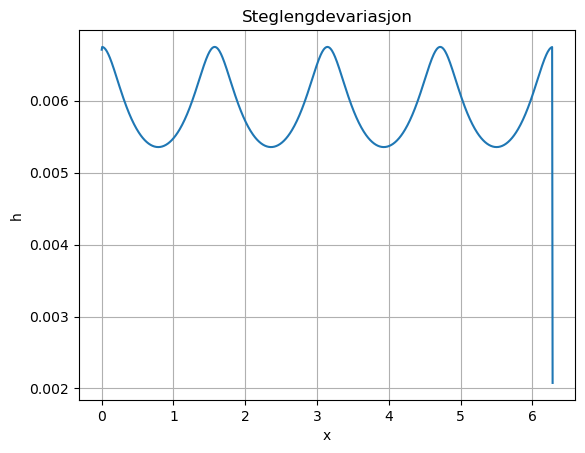

In [41]:
import numpy as np
import matplotlib.pyplot as plt


def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

def solve_rk(tol, alpha, h0):
    x = 0.0
    x_end = 2*np.pi
    h = 0.1
    tol = 10**(-7)
    alpha = 0.8
    y_init = np.array([0, 2])
    y = y_init.copy()

    x_list = [x]
    y_list = [y[0]]
    y_der = [y[1]]
    h_list = []

    while x < x_end:
        if x + h > x_end:
            h = x_end - x

        k1 = f(x, y)
        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
        est = np.linalg.norm(y_next - z_next)

        if est < tol:
            x = x + h
            y = y_next

            x_list.append(x)
            y_list.append(y[0])
            y_der.append(y[1])
            h_list.append(h)

        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

plt.plot(x_list, y_list, label="y(x)", color = "hotpink")
plt.plot(x_list, y_der, label="y'(x)", color = "purple")
plt.xlabel("x")
plt.ylabel("y, y'")
plt.title("Løsning av førsteordens differensialligning")
plt.legend()
plt.grid()
plt.show()

plt.plot(x_list[:-1], h_list)
plt.title("Steglengdevariasjon")
plt.xlabel("x")
plt.ylabel("h")
plt.grid()
plt.show()

#### Kommentar til kode:

Ved bruk av Runge-Kutta-metode styres steglengden av feilen $est = \lVert \vec{y}_{n+1} - \vec{z}_{n+1}\rVert$ som justeres av $h_{new} = \alpha ·h·(\frac{tol}{est})^{1/3}$. Dette medfører at en liten feil gir økning av steglengde $h$, og en stor feil vil nedjustere $h$. Størrelsen på feilen avhenger av krumningen til $\lVert y''(x) \rVert$. En stor krumning, $\lVert y''(x) \rVert$, tilsier en rask retningsendring for løsningen, som dermed resulterer i større feilestimat $est$, og mindre steglengde $h$.

Som kjent er løsningen på porblemet en sinus-funksjon, altså er løsningen periodisk. Dette gjelder også for krumningen som resultert i plottet ovenfor. Dermed varierer feilen og steglengden også periodisk, noe som gir $h(x)$ et oscillerende mønster. Sammenhengden mellom $h(x)$ og løsningen kan illustreres ved å plotte $\frac{1}{h(x)}$. Ved å normalisere $h(x)$ og $\lVert y''(x) \rVert$ viser det at $\frac{1}{h(x)}$ har lik form som $\lVert y''(x) \rVert$. Altså er steglengden $h(x)$ omtrent invers proporsjonal med krumningen.


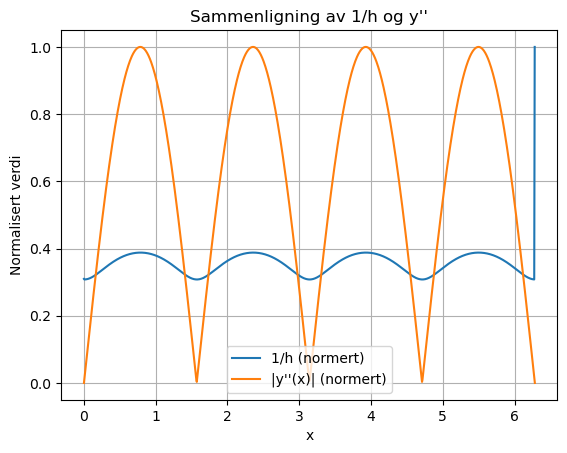

In [40]:
x = np.linspace(0, 2*np.pi, 1000)

y_dd = np.abs(-4*np.sin(2*x_dense))

# 1/h fra metoden
h_inv = 1/np.array(h_list)

# normalisering
h_inv_norm = h_inv / np.max(h_inv)
y_dd_norm = y_dd / np.max(y_dd)

# plott
plt.plot(x_list[:-1], h_inv_norm, label="1/h (normert)")
plt.plot(x, y_dd_norm, label="|y''(x)| (normert)")

plt.title("Sammenligning av 1/h og y''")
plt.xlabel("x")
plt.ylabel("Normalisert verdi")
plt.legend()
plt.grid()
plt.show()